In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import pyarrow
import matplotlib.pyplot as plt
from IPython.display import display


project_root = Path.cwd().parent
sys.path.append(str(project_root))

df1 = pl.read_parquet(
    "../src/preprocessing/Fix_Prob/AROME_METAR_features.parquet"
)
df = pl.read_csv("../src//preprocessing/newline/Dataset_features.csv")

In [6]:
import polars as pl
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve
)



# =====================================================
# 2. Créer les variables temporelles
# =====================================================

df = df.with_columns([
    pl.col("datetime").dt.year().alias("year"),
    pl.col("datetime").dt.hour().alias("hour"),
    pl.col("datetime").dt.ordinal_day().alias("day_of_year")
])

df = df.with_columns([
    (2 * np.pi * pl.col("hour") / 24)
        .sin()
        .alias("hour_sin"),

    (2 * np.pi * pl.col("hour") / 24)
        .cos()
        .alias("hour_cos"),

    (2 * np.pi * pl.col("day_of_year") / 365.25)
        .sin()
        .alias("doy_sin"),

    (2 * np.pi * pl.col("day_of_year") / 365.25)
        .cos()
        .alias("doy_cos")
])

# =====================================================
# 3. Choisir les variables
# =====================================================

features = [
    "u10",
    "v10",
    "t2m",
    "rh2m",

    "u850",
    "v850",

    "u950",
    "v950",

    "psurf",

    "u_gust60",
    "v_gust60",

    "tke20m",
    "edr20m",
    "pblh",

    "lat",
    "lon",
    "elevation_m",

    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

target = "has_gust"

# =====================================================
# 4. Split chronologique
# =====================================================

train = df.filter(
    pl.col("year").is_between(2021, 2023)
)

validation = df.filter(
    pl.col("year") == 2024
)

test = df.filter(
    pl.col("year") == 2025
)

print("Train :", train.shape)
print("Validation :", validation.shape)
print("Test :", test.shape)

# =====================================================
# 5. Vérifier la proportion de rafales
# =====================================================

print("\nTaux de rafales :")

print(
    "Train :",
    train.select(pl.col(target).mean()).item()
)

print(
    "Validation :",
    validation.select(pl.col(target).mean()).item()
)

print(
    "Test :",
    test.select(pl.col(target).mean()).item()
)

# =====================================================
# 6. Transformer pour XGBoost
# =====================================================

X_train = train.select(features).to_pandas()
y_train = train.select(target).to_series().to_numpy()

X_validation = validation.select(features).to_pandas()
y_validation = validation.select(target).to_series().to_numpy()

X_test = test.select(features).to_pandas()
y_test = test.select(target).to_series().to_numpy()

# =====================================================
# 7. Convertir la cible en entier
# =====================================================

y_train = y_train.astype(int)
y_validation = y_validation.astype(int)
y_test = y_test.astype(int)

# =====================================================
# 8. Calculer scale_pos_weight
# =====================================================

nb_negatifs = (y_train == 0).sum()
nb_positifs = (y_train == 1).sum()

scale_pos_weight = nb_negatifs / nb_positifs

print("\nNombre classe 0 :", nb_negatifs)
print("Nombre classe 1 :", nb_positifs)
print("scale_pos_weight :", scale_pos_weight)

# =====================================================
# 9. Créer le modèle XGBoost
# =====================================================

modele = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,
    reg_alpha=0,
    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

# =====================================================
# 10. Entraînement
# =====================================================

modele.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_validation, y_validation)
    ],
    verbose=False
)

print("\nEntraînement terminé.")

# =====================================================
# 11. Probabilités validation
# =====================================================

proba_validation = modele.predict_proba(
    X_validation
)[:, 1]

pr_auc_validation = average_precision_score(
    y_validation,
    proba_validation
)

print("\nPR-AUC validation :", pr_auc_validation)

# =====================================================
# 12. Chercher le meilleur seuil selon F1
# =====================================================

precision, recall, seuils = precision_recall_curve(
    y_validation,
    proba_validation
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (
        precision[:-1]
        + recall[:-1]
        + 1e-10
    )
)

indice_meilleur = np.argmax(f1_scores)

meilleur_seuil = seuils[indice_meilleur]

print("\nMeilleur seuil :", meilleur_seuil)

print(
    "Precision validation :",
    precision[indice_meilleur]
)

print(
    "Recall validation :",
    recall[indice_meilleur]
)

print(
    "F1 validation :",
    f1_scores[indice_meilleur]
)

# =====================================================
# 13. Prédictions validation
# =====================================================

prediction_validation = (
    proba_validation >= meilleur_seuil
).astype(int)

print("\nVALIDATION 2024")

print(
    classification_report(
        y_validation,
        prediction_validation,
        digits=3
    )
)

print(
    confusion_matrix(
        y_validation,
        prediction_validation
    )
)

# =====================================================
# 14. Probabilités test
# =====================================================

proba_test = modele.predict_proba(
    X_test
)[:, 1]

# =====================================================
# 15. Appliquer le seuil choisi sur validation
# =====================================================

prediction_test = (
    proba_test >= meilleur_seuil
).astype(int)

# =====================================================
# 16. Résultats test 2025
# =====================================================

print("\n==============================")
print("TEST 2025")
print("==============================")

print(
    classification_report(
        y_test,
        prediction_test,
        digits=3
    )
)

print("\nMatrice de confusion :")

print(
    confusion_matrix(
        y_test,
        prediction_test
    )
)

pr_auc_test = average_precision_score(
    y_test,
    proba_test
)

print("\nPR-AUC test :", pr_auc_test)

# =====================================================
# 17. Importance des variables
# =====================================================

importances = modele.feature_importances_

ordre = np.argsort(importances)[::-1]

print("\nVariables les plus importantes :")

for i in ordre:
    print(
        features[i],
        round(importances[i], 5)
    )

Train : (491053, 28)
Validation : (196441, 28)
Test : (121420, 28)

Taux de rafales :
Train : 0.028815626826432177
Validation : 0.029148701136728076
Test : 0.03666611760830176

Nombre classe 0 : 476903
Nombre classe 1 : 14150
scale_pos_weight : 33.70339222614841

Entraînement terminé.

PR-AUC validation : 0.39773996491944663

Meilleur seuil : 0.85531616
Precision validation : 0.5729830148619958
Recall validation : 0.377052043311212
F1 validation : 0.4548135664151559

VALIDATION 2024
              precision    recall  f1-score   support

           0      0.981     0.992     0.986    190715
           1      0.573     0.377     0.455      5726

    accuracy                          0.974    196441
   macro avg      0.777     0.684     0.721    196441
weighted avg      0.970     0.974     0.971    196441

[[189106   1609]
 [  3567   2159]]

TEST 2025
              precision    recall  f1-score   support

           0      0.974     0.988     0.981    116968
           1      0.488     0.

In [5]:
import polars as pl
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve
)

# =====================================================
# 1. Variables sans géographie
# =====================================================

features_sans_geo = [
    "u10",
    "v10",
    "t2m",
    "rh2m",

    "u850",
    "v850",

    "u950",
    "v950",

    "psurf",

    "u_gust60",
    "v_gust60",

    "tke20m",
    "edr20m",
    "pblh",

    # Temps
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

target = "has_gust"


# =====================================================
# 2. Préparer les jeux de données
# =====================================================

X_train_sans_geo = train.select(features_sans_geo).to_pandas()
y_train_sans_geo = train.select(target).to_series().to_numpy().astype(int)

X_validation_sans_geo = validation.select(features_sans_geo).to_pandas()
y_validation_sans_geo = validation.select(target).to_series().to_numpy().astype(int)

X_test_sans_geo = test.select(features_sans_geo).to_pandas()
y_test_sans_geo = test.select(target).to_series().to_numpy().astype(int)


# =====================================================
# 3. Calculer scale_pos_weight
# =====================================================

nb_negatifs = (y_train_sans_geo == 0).sum()
nb_positifs = (y_train_sans_geo == 1).sum()

scale_pos_weight = nb_negatifs / nb_positifs

print("Nombre classe 0 :", nb_negatifs)
print("Nombre classe 1 :", nb_positifs)
print("scale_pos_weight :", scale_pos_weight)


# =====================================================
# 4. Créer le modèle
# =====================================================

modele_sans_geo = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,
    reg_alpha=0,
    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)


# =====================================================
# 5. Entraînement
# =====================================================

modele_sans_geo.fit(
    X_train_sans_geo,
    y_train_sans_geo,
    eval_set=[
        (X_train_sans_geo, y_train_sans_geo),
        (X_validation_sans_geo, y_validation_sans_geo)
    ],
    verbose=False
)

print("\nEntraînement terminé.")


# =====================================================
# 6. Probabilités validation
# =====================================================

proba_validation = modele_sans_geo.predict_proba(
    X_validation_sans_geo
)[:, 1]

pr_auc_validation = average_precision_score(
    y_validation_sans_geo,
    proba_validation
)

print("\nPR-AUC validation :", pr_auc_validation)


# =====================================================
# 7. Chercher le meilleur seuil sur validation
# =====================================================

precision, recall, seuils = precision_recall_curve(
    y_validation_sans_geo,
    proba_validation
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (
        precision[:-1]
        + recall[:-1]
        + 1e-10
    )
)

indice_meilleur = np.argmax(f1_scores)

meilleur_seuil_sans_geo = seuils[indice_meilleur]

print("\nMeilleur seuil :", meilleur_seuil_sans_geo)
print("Precision validation :", precision[indice_meilleur])
print("Recall validation :", recall[indice_meilleur])
print("F1 validation :", f1_scores[indice_meilleur])


# =====================================================
# 8. Résultats validation
# =====================================================

prediction_validation = (
    proba_validation >= meilleur_seuil_sans_geo
).astype(int)

print("\n==============================")
print("VALIDATION 2024")
print("==============================")

print(
    classification_report(
        y_validation_sans_geo,
        prediction_validation,
        digits=3
    )
)

print("Matrice de confusion :")
print(
    confusion_matrix(
        y_validation_sans_geo,
        prediction_validation
    )
)


# =====================================================
# 9. Test 2025
# =====================================================

proba_test = modele_sans_geo.predict_proba(
    X_test_sans_geo
)[:, 1]

prediction_test = (
    proba_test >= meilleur_seuil_sans_geo
).astype(int)

print("\n==============================")
print("TEST 2025")
print("==============================")

print(
    classification_report(
        y_test_sans_geo,
        prediction_test,
        digits=3
    )
)

print("Matrice de confusion :")
print(
    confusion_matrix(
        y_test_sans_geo,
        prediction_test
    )
)

pr_auc_test = average_precision_score(
    y_test_sans_geo,
    proba_test
)

print("\nPR-AUC test :", pr_auc_test)


# =====================================================
# 10. Importance des variables
# =====================================================

importances = modele_sans_geo.feature_importances_

ordre = np.argsort(importances)[::-1]

print("\nVariables les plus importantes :")

for i in ordre:
    print(
        features_sans_geo[i],
        round(importances[i], 5)
    )

Nombre classe 0 : 476903
Nombre classe 1 : 14150
scale_pos_weight : 33.70339222614841

Entraînement terminé.

PR-AUC validation : 0.2942158674225014

Meilleur seuil : 0.7717457
Precision validation : 0.34716530054644806
Recall validation : 0.3550471533356619
F1 validation : 0.35106199269737287

VALIDATION 2024
              precision    recall  f1-score   support

           0      0.981     0.980     0.980    190715
           1      0.347     0.355     0.351      5726

    accuracy                          0.962    196441
   macro avg      0.664     0.668     0.666    196441
weighted avg      0.962     0.962     0.962    196441

Matrice de confusion :
[[186892   3823]
 [  3693   2033]]

TEST 2025
              precision    recall  f1-score   support

           0      0.973     0.974     0.974    116968
           1      0.307     0.299     0.303      4452

    accuracy                          0.950    121420
   macro avg      0.640     0.637     0.638    121420
weighted avg      0.

In [4]:
print(df.columns)
print(df.schema)

['station', 'indicatif', 'datetime', 'longitude', 'latitude', 'u10', 'v10', 't2m', 'rh2m', 'u850', 'v850', 'u950', 'v950', 'psurf', 'u_gust60', 'v_gust60', 'tke20m', 'edr20m', 'pblh', 'wind_mean', 'wind_final', 'has_gust', 'speed_10', 'speed_850', 'speed_950', 'speed_gust60', 'dir_10', 'dir_10_sin', 'dir_10_cos', 'dir_850', 'dir_850_sin', 'dir_850_cos', 'dir_950', 'dir_950_sin', 'dir_950_cos', 'shear_10_950', 'shear_950_850', 'shear_10_850', 'gust_ratio_arome', 'speed_10_was_floored', 'hour', 'month', 'day_of_year', 'year', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'season', 'station_idx', 'arome_error', 'correction_target']
Schema({'station': Int64, 'indicatif': String, 'datetime': Datetime(time_unit='us', time_zone=None), 'longitude': Float64, 'latitude': Float64, 'u10': Float64, 'v10': Float64, 't2m': Float64, 'rh2m': Float64, 'u850': Float64, 'v850': Float64, 'u950': Float64, 'v950': Float64, 'psurf': Float64, 'u_gust60': Float64, 'v_gust60': Float64, 'tke20m': Float64, 'edr20m

In [5]:
df = df.with_columns(
    pl.col("datetime")
      .cast(pl.Datetime, strict=False)
      .alias("datetime")
)

In [6]:
df.select(
    pl.col("datetime").min().alias("date_min"),
    pl.col("datetime").max().alias("date_max")
)

date_min,date_max
datetime[μs],datetime[μs]
2021-01-01 00:00:00,2025-08-24 21:00:00


In [7]:
features_numeriques = [
    "longitude",
    "latitude",
    "u10",
    "v10",
    "t2m",
    "rh2m",
    "u850",
    "v850",
    "u950",
    "v950",
    "psurf",
    "u_gust60",
    "v_gust60",
    "tke20m",
    "edr20m",
    "pblh",
    "speed_10",
    "speed_850",
    "speed_950",
    "speed_gust60",
    "dir_10_sin",
    "dir_10_cos",
    "dir_850_sin",
    "dir_850_cos",
    "dir_950_sin",
    "dir_950_cos",
    "shear_10_950",
    "shear_950_850",
    "shear_10_850",
    "gust_ratio_arome",
    "speed_10_was_floored",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

features_categorielles = [
    "station"
]

target = "has_gust"

In [8]:
colonnes_modele = (
    features_numeriques
    + features_categorielles
    + [target, "datetime"]
)

colonnes_absentes = [
    colonne
    for colonne in colonnes_modele
    if colonne not in df.columns
]

print("Colonnes absentes :", colonnes_absentes)

Colonnes absentes : []


In [9]:
df_model = (
    df.select(colonnes_modele)
      .filter(pl.col(target).is_not_null())
      .sort("datetime")
)

df_model.head()

longitude,latitude,u10,v10,t2m,rh2m,u850,v850,u950,v950,psurf,u_gust60,v_gust60,tke20m,edr20m,pblh,speed_10,speed_850,speed_950,speed_gust60,dir_10_sin,dir_10_cos,dir_850_sin,dir_850_cos,dir_950_sin,dir_950_cos,shear_10_950,shear_950_850,shear_10_850,gust_ratio_arome,speed_10_was_floored,hour_sin,hour_cos,doy_sin,doy_cos,station,has_gust,datetime
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,f64,f64,f64,f64,i64,i64,datetime[μs]
-2.95,35.275,-1.496852,2.34412,286.48999,0.765352,-0.811874,1.031498,-1.686752,2.179523,101992.625,-2.744247,5.027328,0.426271,0.005509,228.499999,2.78127,1.31268,2.755985,5.727558,0.53819,-0.842824,0.618486,-0.785796,0.612032,-0.790833,0.251305,1.44339,1.480598,2.059332,0,0.0,1.0,0.017202,0.999852,60338,0,2021-01-01 00:00:00
-4.975,33.925,3.202427,2.061598,276.724029,0.872056,7.157641,2.284971,3.609188,1.960571,95058.125,3.2069664,2.0657444,0.000001,0.000001,10.0,3.808638,7.513516,4.10732,3.8147,-0.840833,-0.541295,-0.952635,-0.304115,-0.878721,-0.477336,0.419119,3.563251,3.961517,1.001592,0,0.0,1.0,0.017202,0.999852,60141,0,2021-01-01 00:00:00
-4.4,31.925,0.647739,-0.74309,279.329498,0.676988,3.313891,1.659971,0.640438,-0.726929,90017.125,0.652279,-0.746756,0.000001,0.000001,10.0,0.985773,3.706397,0.968807,0.99152,-0.657088,0.753814,-0.8941,-0.447867,-0.661059,0.750334,0.017734,3.583943,3.589299,1.00583,0,0.0,1.0,0.017202,0.999852,60210,0,2021-01-01 00:00:00
-5.525,33.875,1.085239,1.452223,276.774811,0.935045,4.329516,1.074034,1.562313,1.202759,95328.125,1.0897789,1.4485569,0.000001,0.000001,10.0,1.812925,4.460747,1.971662,1.812715,-0.598613,-0.801039,-0.970581,-0.240774,-0.792384,-0.610023,0.53836,2.770196,3.266246,0.999884,0,0.0,1.0,0.017202,0.999852,60150,0,2021-01-01 00:00:00
-1.925,34.775,3.819614,3.272535,277.336334,0.832994,10.501391,-4.105654,7.921688,4.952759,96118.125,3.8241539,3.2766819,0.000001,0.000001,10.0,5.029805,11.275443,9.342535,5.03595,-0.759396,-0.650629,-0.931351,0.364124,-0.847916,-0.53013,4.43285,9.418583,9.954085,1.001222,0,0.0,1.0,0.017202,0.999852,60115,0,2021-01-01 00:00:00


In [10]:
print("Dimensions :", df_model.shape)

print(
    df_model
    .group_by(target)
    .len()
    .sort(target)
)

Dimensions : (825829, 38)
shape: (2, 2)
┌──────────┬────────┐
│ has_gust ┆ len    │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 0        ┆ 808509 │
│ 1        ┆ 17320  │
└──────────┴────────┘


In [11]:
train_pl = df_model.filter(
    pl.col("datetime") < pl.datetime(2024, 1, 1)
)

validation_pl = df_model.filter(
    (pl.col("datetime") >= pl.datetime(2024, 1, 1)) &
    (pl.col("datetime") < pl.datetime(2025, 1, 1))
)

test_pl = df_model.filter(
    pl.col("datetime") >= pl.datetime(2025, 1, 1)
)

In [12]:
for nom, data in [
    ("Train", train_pl),
    ("Validation", validation_pl),
    ("Test", test_pl)
]:
    print(nom)
    print(
        data.select(
            pl.col("datetime").min().alias("debut"),
            pl.col("datetime").max().alias("fin"),
            pl.len().alias("nombre_lignes"),
            pl.col("has_gust").sum().alias("nombre_gust"),
            (pl.col("has_gust").mean() * 100)
                .round(2)
                .alias("pourcentage_gust")
        )
    )

Train
shape: (1, 5)
┌─────────────────────┬─────────────────────┬───────────────┬─────────────┬──────────────────┐
│ debut               ┆ fin                 ┆ nombre_lignes ┆ nombre_gust ┆ pourcentage_gust │
│ ---                 ┆ ---                 ┆ ---           ┆ ---         ┆ ---              │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32           ┆ i64         ┆ f64              │
╞═════════════════════╪═════════════════════╪═══════════════╪═════════════╪══════════════════╡
│ 2021-01-01 00:00:00 ┆ 2023-12-31 23:00:00 ┆ 498467        ┆ 10639       ┆ 2.13             │
└─────────────────────┴─────────────────────┴───────────────┴─────────────┴──────────────────┘
Validation
shape: (1, 5)
┌─────────────────────┬─────────────────────┬───────────────┬─────────────┬──────────────────┐
│ debut               ┆ fin                 ┆ nombre_lignes ┆ nombre_gust ┆ pourcentage_gust │
│ ---                 ┆ ---                 ┆ ---           ┆ ---         ┆ ---              │
│ dat

In [13]:
features = features_numeriques + features_categorielles

train = train_pl.select(features + [target]).to_pandas()
validation = validation_pl.select(features + [target]).to_pandas()
test = test_pl.select(features + [target]).to_pandas()

In [14]:
X_train = train[features]
y_train = train[target]

X_validation = validation[features]
y_validation = validation[target]

X_test = test[features]
y_test = test[target]

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


preprocessing_numerique = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler())
])

preprocessing_categoriel = Pipeline([
    ("imputation", SimpleImputer(strategy="most_frequent")),
    ("encodage", OneHotEncoder(handle_unknown="ignore"))
])

preprocesseur = ColumnTransformer([
    (
        "numerique",
        preprocessing_numerique,
        features_numeriques
    ),
    (
        "categoriel",
        preprocessing_categoriel,
        features_categorielles
    )
])

In [16]:
modele_global = Pipeline([
    ("preprocessing", preprocesseur),
    (
        "modele",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [17]:
modele_global.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('modele', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['longitude','latitude','u10',...,'doy_sin','doy_cos','station']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categoriel', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [18]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score
)

proba_validation = modele_global.predict_proba(
    X_validation
)[:, 1]

prediction_validation = (
    proba_validation >= 0.5
).astype(int)

In [19]:
print(
    classification_report(
        y_validation,
        prediction_validation,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_validation,
        prediction_validation
    )
)

print(
    "PR-AUC validation :",
    average_precision_score(
        y_validation,
        proba_validation
    )
)

              precision    recall  f1-score   support

           0      0.991     0.811     0.892    199145
           1      0.054     0.596     0.099      3620

    accuracy                          0.807    202765
   macro avg      0.523     0.703     0.496    202765
weighted avg      0.974     0.807     0.878    202765

[[161437  37708]
 [  1463   2157]]
PR-AUC validation : 0.07142637953590945


In [20]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, seuils = precision_recall_curve(
    y_validation,
    proba_validation
)

f1 = (
    2 * precision * recall
    / (precision + recall + 1e-12)
)

indice = np.argmax(f1[:-1])

meilleur_seuil = seuils[indice]

print("Meilleur seuil :", meilleur_seuil)
print("F1 validation :", f1[indice])
print("Précision validation :", precision[indice])
print("Rappel validation :", recall[indice])

Meilleur seuil : 0.9223553774686849
F1 validation : 0.11709461484617632
Précision validation : 0.0917201439974957
Rappel validation : 0.16187845303867404


In [21]:
proba_test = modele_global.predict_proba(
    X_test
)[:, 1]

prediction_test = (
    proba_test >= meilleur_seuil
).astype(int)

In [22]:
print(
    classification_report(
        y_test,
        prediction_test,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_test,
        prediction_test
    )
)

print(
    "PR-AUC test :",
    average_precision_score(
        y_test,
        proba_test
    )
)

              precision    recall  f1-score   support

           0      0.977     0.967     0.972    121536
           1      0.078     0.110     0.091      3061

    accuracy                          0.946    124597
   macro avg      0.528     0.539     0.532    124597
weighted avg      0.955     0.946     0.951    124597

[[117540   3996]
 [  2723    338]]
PR-AUC test : 0.06157848457014446


## Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

modele_rf = Pipeline([
    ("preprocessing", preprocesseur),
    (
        "modele",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

modele_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('modele', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['longitude','latitude','u10',...,'doy_sin','doy_cos','station']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categoriel', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [24]:
proba_validation_rf = modele_rf.predict_proba(
    X_validation
)[:, 1]

In [25]:
prediction_validation_rf = (
    proba_validation_rf >= 0.6
).astype(int)

In [26]:

print(
    classification_report(
        y_validation,
        prediction_validation_rf
    )
)

              precision    recall  f1-score   support

           0       0.99      0.94      0.96    199145
           1       0.09      0.33      0.15      3620

    accuracy                           0.93    202765
   macro avg       0.54      0.64      0.56    202765
weighted avg       0.97      0.93      0.95    202765



In [27]:
print(confusion_matrix(y_validation, prediction_validation_rf))

[[187716  11429]
 [  2425   1195]]


In [28]:
proba_test_rf = modele_rf.predict_proba(X_test)[:, 1]

prediction_test_rf = (
    proba_test_rf >= 0.6
).astype(int)

In [29]:
print(
    classification_report(
        y_test,
        prediction_test_rf,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_test,
        prediction_test_rf
    )
)

print(
    "PR-AUC test :",
    average_precision_score(
        y_test,
        proba_test_rf
    )
)

              precision    recall  f1-score   support

           0      0.982     0.937     0.959    121536
           1      0.112     0.314     0.165      3061

    accuracy                          0.922    124597
   macro avg      0.547     0.626     0.562    124597
weighted avg      0.961     0.922     0.939    124597

[[113884   7652]
 [  2099    962]]
PR-AUC test : 0.08347783638465746


In [31]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

modele_xgb = Pipeline([
    ("preprocessing", preprocesseur),
    ("modele", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

modele_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('modele', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['longitude','latitude','u10',...,'doy_sin','doy_cos','station']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categoriel', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [35]:
proba_validation_xgb = modele_xgb.predict_proba(
    X_validation
)[:, 1]

In [39]:
prediction_validation_xgb = (
    proba_validation_xgb >= 0.1
).astype(int)

In [40]:
print(
    classification_report(
        y_validation,
        prediction_validation_xgb,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_validation,
        prediction_validation_xgb
    )
)

print(
    "PR-AUC validation :",
    average_precision_score(
        y_validation,
        proba_validation_xgb
    )
)

              precision    recall  f1-score   support

           0      0.987     0.955     0.971    199145
           1      0.111     0.312     0.164      3620

    accuracy                          0.943    202765
   macro avg      0.549     0.633     0.567    202765
weighted avg      0.971     0.943     0.956    202765

[[190122   9023]
 [  2492   1128]]
PR-AUC validation : 0.07839516186666828


In [42]:
proba_test_xgb = modele_xgb.predict_proba(X_test)[:, 1]

prediction_test_xgb = (
    proba_test_xgb >= 0.1
).astype(int)

print(
    classification_report(
        y_test,
        prediction_test_xgb,
        digits=3,
        zero_division=0
    )
)

print(
    confusion_matrix(
        y_test,
        prediction_test_xgb
    )
)

print(
    "PR-AUC test :",
    average_precision_score(
        y_test,
        proba_test_xgb
    )
)

              precision    recall  f1-score   support

           0      0.981     0.951     0.966    121536
           1      0.126     0.279     0.174      3061

    accuracy                          0.935    124597
   macro avg      0.554     0.615     0.570    124597
weighted avg      0.960     0.935     0.947    124597

[[115625   5911]
 [  2206    855]]
PR-AUC test : 0.08882246288734577


In [43]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

print("Régression logistique")
print("Précision :", precision_score(y_test, prediction_test))
print("Rappel :", recall_score(y_test, prediction_test))
print("F1 :", f1_score(y_test, prediction_test))
print("PR-AUC :", average_precision_score(y_test, proba_test))

print("\nRandom Forest")
print("Précision :", precision_score(y_test, prediction_test_rf))
print("Rappel :", recall_score(y_test, prediction_test_rf))
print("F1 :", f1_score(y_test, prediction_test_rf))
print("PR-AUC :", average_precision_score(y_test, proba_test_rf))

print("\nXGBoost")
print("Précision :", precision_score(y_test, prediction_test_xgb))
print("Rappel :", recall_score(y_test, prediction_test_xgb))
print("F1 :", f1_score(y_test, prediction_test_xgb))
print("PR-AUC :", average_precision_score(y_test, proba_test_xgb))

Régression logistique
Précision : 0.07798800184586986
Rappel : 0.11042143090493303
F1 : 0.0914131169709263
PR-AUC : 0.06157848457014446

Random Forest
Précision : 0.11167866264221035
Rappel : 0.3142763802678863
F1 : 0.164796573875803
PR-AUC : 0.08347783638465746

XGBoost
Précision : 0.12636712976647946
Rappel : 0.27932048350212346
F1 : 0.17401037956650045
PR-AUC : 0.08882246288734577


In [60]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight recommandé :", ratio)

scale_pos_weight recommandé : 45.85280571482282


In [62]:
import numpy as np
import xgboost as xgb

from sklearn.metrics import average_precision_score
from sklearn.model_selection import ParameterSampler

# Calcul du déséquilibre des classes
nombre_negatifs = (y_train == 0).sum()
nombre_positifs = (y_train == 1).sum()
ratio = nombre_negatifs / nombre_positifs

print("scale_pos_weight :", ratio)

# Récupérer le préprocesseur déjà entraîné
preprocesseur = modele_xgb.named_steps["preprocessing"]

# Ne pas refaire fit_transform ici :
# le pipeline a normalement déjà entraîné ce préprocesseur
X_train_transforme = preprocesseur.transform(X_train)
X_validation_transforme = preprocesseur.transform(X_validation)

grille = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}

combinaisons = list(
    ParameterSampler(
        grille,
        n_iter=30,
        random_state=42
    )
)

meilleur_score = -1
meilleurs_params = None
meilleur_xgb = None

for numero, params in enumerate(combinaisons, start=1):

    modele = xgb.XGBClassifier(
        n_estimators=300,
        **params,
        scale_pos_weight=ratio,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    modele.fit(
        X_train_transforme,
        y_train
    )

    proba_validation = modele.predict_proba(
        X_validation_transforme
    )[:, 1]

    score = average_precision_score(
        y_validation,
        proba_validation
    )

    print(
        f"Essai {numero}/{len(combinaisons)} "
        f"- PR-AUC : {score:.5f}"
    )

    if score > meilleur_score:
        meilleur_score = score
        meilleurs_params = params.copy()
        meilleur_xgb = modele

print("\nMeilleur PR-AUC validation :", meilleur_score)
print("Meilleurs paramètres :", meilleurs_params)

scale_pos_weight : 45.85280571482282
Essai 1/30 - PR-AUC : 0.07970
Essai 2/30 - PR-AUC : 0.06465
Essai 3/30 - PR-AUC : 0.08316
Essai 4/30 - PR-AUC : 0.08071
Essai 5/30 - PR-AUC : 0.07774
Essai 6/30 - PR-AUC : 0.07390
Essai 7/30 - PR-AUC : 0.08225
Essai 8/30 - PR-AUC : 0.08433
Essai 9/30 - PR-AUC : 0.07585
Essai 10/30 - PR-AUC : 0.08773
Essai 11/30 - PR-AUC : 0.07812
Essai 12/30 - PR-AUC : 0.07836
Essai 13/30 - PR-AUC : 0.07555
Essai 14/30 - PR-AUC : 0.06557
Essai 15/30 - PR-AUC : 0.06593
Essai 16/30 - PR-AUC : 0.07720
Essai 17/30 - PR-AUC : 0.07370
Essai 18/30 - PR-AUC : 0.07594
Essai 19/30 - PR-AUC : 0.08205
Essai 20/30 - PR-AUC : 0.07869
Essai 21/30 - PR-AUC : 0.09540
Essai 22/30 - PR-AUC : 0.07920
Essai 23/30 - PR-AUC : 0.08950
Essai 24/30 - PR-AUC : 0.08917
Essai 25/30 - PR-AUC : 0.07404
Essai 26/30 - PR-AUC : 0.06550
Essai 27/30 - PR-AUC : 0.07639
Essai 28/30 - PR-AUC : 0.07444
Essai 29/30 - PR-AUC : 0.07485
Essai 30/30 - PR-AUC : 0.07493

Meilleur PR-AUC validation : 0.0953983485

In [63]:
import numpy as np
from sklearn.metrics import precision_recall_curve

proba_validation_optimise = meilleur_xgb.predict_proba(
    X_validation_transforme
)[:, 1]

precisions, rappels, seuils = precision_recall_curve(
    y_validation,
    proba_validation_optimise
)

f1_scores = (
    2 * precisions * rappels
    / (precisions + rappels + 1e-10)
)

meilleur_index = np.argmax(f1_scores[:-1])

seuil_xgb_optimise = seuils[meilleur_index]

print("Meilleur seuil :", seuil_xgb_optimise)
print("F1 validation :", f1_scores[meilleur_index])
print("Précision validation :", precisions[meilleur_index])
print("Rappel validation :", rappels[meilleur_index])

Meilleur seuil : 0.8164588
F1 validation : 0.16901408446930286
Précision validation : 0.11303861219921657
Rappel validation : 0.33480662983425413


In [65]:
X_test_transforme = preprocesseur.transform(X_test)

In [66]:
from sklearn.metrics import classification_report, average_precision_score

proba_test_optimise = meilleur_xgb.predict_proba(
    X_test_transforme
)[:, 1]

pred_test_optimise = (
    proba_test_optimise >= seuil_xgb_optimise
).astype(int)

print(
    classification_report(
        y_test,
        pred_test_optimise,
        digits=3,
        zero_division=0
    )
)

print(
    "PR-AUC test :",
    average_precision_score(y_test, proba_test_optimise)
)

              precision    recall  f1-score   support

           0      0.981     0.947     0.964    121536
           1      0.121     0.288     0.170      3061

    accuracy                          0.931    124597
   macro avg      0.551     0.618     0.567    124597
weighted avg      0.960     0.931     0.945    124597

PR-AUC test : 0.08797988480870515


In [67]:
ratio_base = (y_train == 0).sum() / (y_train == 1).sum()
print(ratio_base)

45.85280571482282


In [68]:
valeurs_ratio = [
    ratio_base * 0.5,
    ratio_base,
    ratio_base * 1.5,
    ratio_base * 2
]

In [69]:
from sklearn.metrics import average_precision_score
import xgboost as xgb

resultats_ratio = []

for valeur in valeurs_ratio:
    modele = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=valeur,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    modele.fit(X_train_transforme, y_train)

    proba_validation = modele.predict_proba(
        X_validation_transforme
    )[:, 1]

    pr_auc = average_precision_score(
        y_validation,
        proba_validation
    )

    resultats_ratio.append((valeur, pr_auc))

    print(
        "scale_pos_weight:",
        round(valeur, 2),
        "PR-AUC:",
        pr_auc
    )

scale_pos_weight: 22.93 PR-AUC: 0.08298692157957872
scale_pos_weight: 45.85 PR-AUC: 0.08218021607499745
scale_pos_weight: 68.78 PR-AUC: 0.08117125982439044
scale_pos_weight: 91.71 PR-AUC: 0.0793355503653886


In [70]:
import pandas as pd

# Nom des variables après le prétraitement
noms_variables = modele_xgb.named_steps["preprocessing"].get_feature_names_out()

# Importance des variables
importance = modele_xgb.named_steps["modele"].feature_importances_

df_importance = pd.DataFrame({
    "Variable": noms_variables,
    "Importance": importance
})

df_importance = df_importance.sort_values(
    by="Importance",
    ascending=False
)

print(df_importance.head(20))

                       Variable  Importance
52    categoriel__station_60220    0.170854
0          numerique__longitude    0.155611
57    categoriel__station_60280    0.089895
41    categoriel__station_60120    0.076019
35    categoriel__station_60033    0.056263
58    categoriel__station_60285    0.054555
32          numerique__hour_cos    0.042924
19      numerique__speed_gust60    0.031545
36    categoriel__station_60060    0.024378
18         numerique__speed_950    0.024309
31          numerique__hour_sin    0.021353
16          numerique__speed_10    0.017815
50    categoriel__station_60200    0.016456
39    categoriel__station_60107    0.009740
42    categoriel__station_60135    0.009218
29  numerique__gust_ratio_arome    0.009027
34           numerique__doy_cos    0.008966
47    categoriel__station_60156    0.008798
1           numerique__latitude    0.007639
60    categoriel__station_60340    0.007301


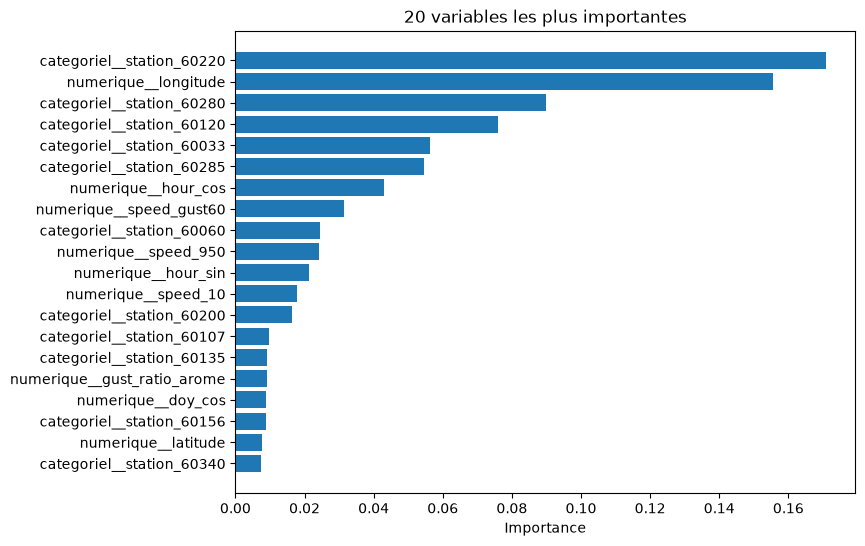

In [71]:
import matplotlib.pyplot as plt

top20 = df_importance.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Variable"], top20["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("20 variables les plus importantes")
plt.show()

In [72]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Importance par permutation
resultat = permutation_importance(
    modele_xgb,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_perm = pd.DataFrame({
    "Variable": X_validation.columns,
    "Importance": resultat.importances_mean
})

importance_perm = importance_perm.sort_values(
    "Importance",
    ascending=False
)

print(importance_perm.head(20))

         Variable  Importance
19   speed_gust60    0.018935
18      speed_950    0.013973
35        station    0.011793
32       hour_cos    0.010914
17      speed_850    0.007698
16       speed_10    0.007376
31       hour_sin    0.004232
7            v850    0.002266
34        doy_cos    0.002091
15           pblh    0.001463
1        latitude    0.001420
5            rh2m    0.001164
6            u850    0.001103
13         tke20m    0.001041
25    dir_950_cos    0.001005
9            v950    0.000764
23    dir_850_cos    0.000538
10          psurf    0.000532
27  shear_950_850    0.000517
3             v10    0.000462
